# Deep Learning with PyTorch: Hello World 🌍

Welcome! This notebook serves as the "Hello World" equivalent for deep learning with PyTorch. Here, we load a pre-trained **ResNet-101** model (trained on the ImageNet dataset) to classify an input image and inspect its top predictions.

In [ ]:
from torchvision import models

## Step 1: Load a Pre-trained Model

We will use `torchvision.models` to download and load a pre-trained **ResNet-101** network.

In [ ]:
dir(models)

['AlexNet',
 'AlexNet_Weights',
 'ConvNeXt',
 'ConvNeXt_Base_Weights',
 'ConvNeXt_Large_Weights',
 'ConvNeXt_Small_Weights',
 'ConvNeXt_Tiny_Weights',
 'DenseNet',
 'DenseNet121_Weights',
 'DenseNet161_Weights',
 'DenseNet169_Weights',
 'DenseNet201_Weights',
 'EfficientNet',
 'EfficientNet_B0_Weights',
 'EfficientNet_B1_Weights',
 'EfficientNet_B2_Weights',
 'EfficientNet_B3_Weights',
 'EfficientNet_B4_Weights',
 'EfficientNet_B5_Weights',
 'EfficientNet_B6_Weights',
 'EfficientNet_B7_Weights',
 'EfficientNet_V2_L_Weights',
 'EfficientNet_V2_M_Weights',
 'EfficientNet_V2_S_Weights',
 'GoogLeNet',
 'GoogLeNetOutputs',
 'GoogLeNet_Weights',
 'Inception3',
 'InceptionOutputs',
 'Inception_V3_Weights',
 'MNASNet',
 'MNASNet0_5_Weights',
 'MNASNet0_75_Weights',
 'MNASNet1_0_Weights',
 'MNASNet1_3_Weights',
 'MaxVit',
 'MaxVit_T_Weights',
 'MobileNetV2',
 'MobileNetV3',
 'MobileNet_V2_Weights',
 'MobileNet_V3_Large_Weights',
 'MobileNet_V3_Small_Weights',
 'RegNet',
 'RegNet_X_16GF_Weights'

In [ ]:
resnet = models.resnet101(pretrained=True)

/usr/local/lib/python3.13/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet101_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet101_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet101-63fe2227.pth" to /root/.cache/torch/hub/checkpoints/resnet101-63fe2227.pth


100%|██████████| 171M/171M [00:02<00:00, 84.5MB/s]


## Step 2: Define Image Preprocessing Transforms

Neural networks require inputs to be of a specific size and normalized according to the training dataset's statistics (ImageNet mean and standard deviation).

In [ ]:
from torchvision import transforms

In [ ]:
preprocess = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

## Step 3: Load and Inspect the Input Image

We load our target image using the PIL library.

In [ ]:
from PIL import Image
img = Image.open('/content/IMG_1967.jpg')

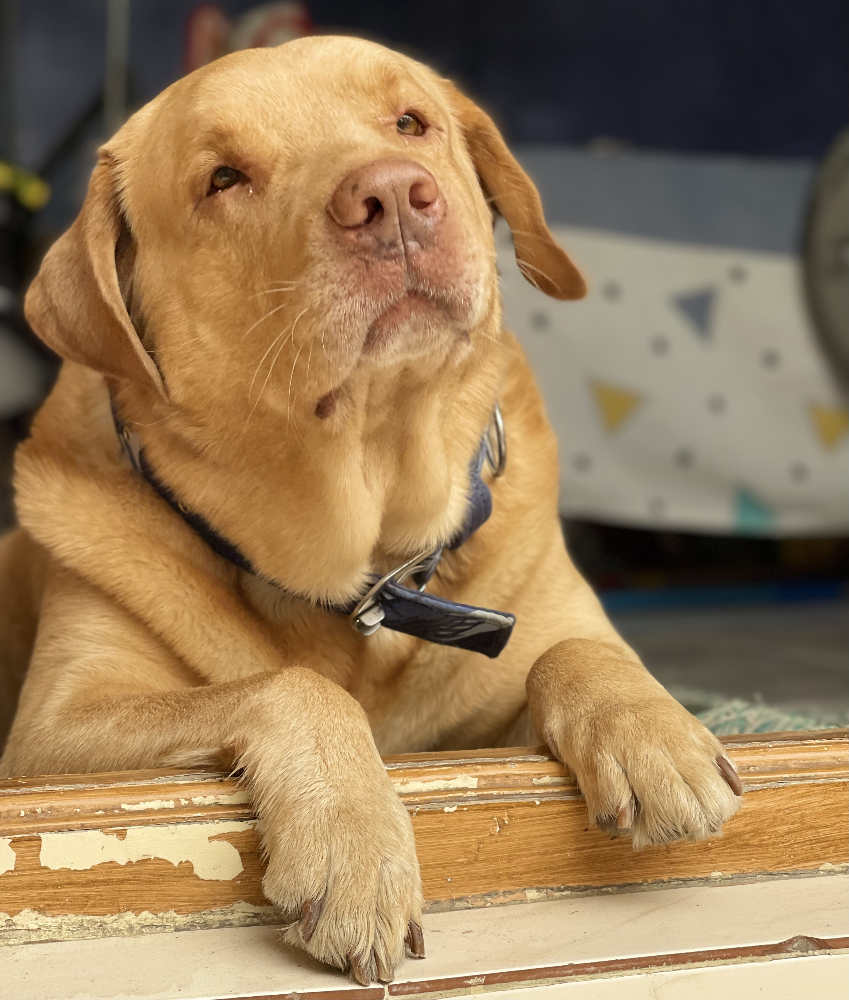

In [ ]:
img

In [ ]:
img.show()

## Step 4: Preprocess and Prepare the Batch

We apply our defined transformation pipeline to the image and add a batch dimension since PyTorch models expect batched inputs (`[batch_size, channels, height, width]`).

In [ ]:
img_t = preprocess(img)

In [ ]:
import torch

batch_t = torch.unsqueeze(img_t, 0)

## Step 5: Inference (Model Evaluation)

We set our model to `eval` mode to disable dropout or batch normalization updates, then pass our batch through the network to get class logits.

In [ ]:
resnet.eval()

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

In [ ]:
out = resnet(batch_t)

In [ ]:
out

tensor([[-1.9531e+00,  1.0784e+00,  1.2319e+00,  8.5434e-01,  1.6314e+00,
          1.0113e+00, -1.2864e-01,  6.2019e+00,  6.8470e+00,  9.6581e-01,
         -8.8781e-01,  7.2932e-01, -1.0153e+00,  2.7811e-01, -4.2359e+00,
          4.9263e-02,  1.1737e+00,  2.0375e+00,  1.6977e+00,  1.5670e+00,
         -2.0063e-01,  2.5319e+00,  4.7029e+00,  3.4234e+00,  7.1274e-01,
         -2.8485e+00, -4.9462e+00, -3.0257e+00, -2.0966e+00,  1.1944e+00,
         -4.0540e+00, -3.0510e+00, -4.5435e+00, -3.1567e-01, -1.5898e+00,
         -5.5347e+00, -2.7159e+00, -3.6359e+00, -2.8632e+00, -1.0667e+00,
         -1.3587e+00, -4.2833e+00, -1.8561e+00, -1.6126e+00, -2.2023e+00,
         -9.4173e-01, -1.5750e+00, -2.9292e+00, -1.9701e+00, -3.4400e+00,
         -2.1522e+00,  9.8635e-01, -2.9657e+00, -2.9633e+00, -1.7493e+00,
         -1.1137e+00, -2.8471e+00, -3.1355e+00, -3.8200e+00, -1.3084e+00,
         -6.0676e-02, -1.2999e+00, -1.6756e+00, -1.1713e+00, -1.5494e+00,
         -1.7718e+00, -1.7616e+00, -2.

## Step 6: Map Logits to ImageNet Classes

To translate our model's numerical outputs into human-readable labels, we load the list of 1,000 ImageNet classes.

In [ ]:
with open('/content/imagenet_classes.txt') as f:
    labels = [line.strip() for line in f.readlines()]

## Step 7: Analyze the Predictions

We extract the class with the highest probability value and list the top 5 predicted classes to understand what features our ResNet-101 model detected.

In [ ]:
index = torch.max(out,1)

In [ ]:
index

torch.return_types.max(
values=tensor([7.1063], grad_fn=<MaxBackward0>),
indices=tensor([296]))

In [ ]:
percentage = torch.nn.functional.softmax(out, dim=1)[0] * 100
labels[index[1]], percentage[index[1]].item()

('ice bear', 11.56676959991455)

In [ ]:
_, indices = torch.sort(out,descending=True)
[(labels[idx], percentage[idx].item()) for idx in indices[0][:5]]

[('ice bear', 11.56676959991455),
 ('hen', 8.92469596862793),
 ('fur coat', 6.75440788269043),
 ('cock', 4.682027339935303),
 ('white wolf', 4.382047653198242)]

### Why did ResNet classify a Labrador retriever as an "ice bear" (polar bear)?

Image classifiers like ResNet-101 look at the entire image context, including both the main subject and the background, rather than isolating the animal like a human would.

Here are the primary reasons why this misclassification happened:

1. **Background Bias:** If your Labrador is yellow, cream, or white and is photographed on a bright background (like snow, light-colored sand, a white blanket, or under overexposed sunlight), the model heavily associates those white background patches with arctic environments, triggering features learned for "ice bears" or "white wolves".
2. **Texture Sensitivity:** Deep convolutional neural networks are highly sensitive to local textures (like wet, thick, or coarse fur) rather than global structures. In fact, **"fur coat"** appearing in the top 5 predictions indicates that the model was heavily focusing on the texture of the coat.
3. **Class Overlap:** In the ImageNet dataset, classes like polar bears and yellow/white retrievers share overlapping features—such as face structure, snout shape, and ear droop—which can easily confuse the model if the background signals lean towards an arctic environment.